In [2]:
import sys

sys.path.append('/Users/user/Documents/Inno/XAI/swin_shapleycam/shapleycam')
sys.path.append('/Users/user/Documents/Inno/XAI/swin_shapleycam/shapleycam/pytorch_grad_cam')
import sys
import os

# Add the parent directory of pytorch_grad_cam to sys.path
sys.path.append(os.path.abspath('./shapleycam'))  # Adjust the path as necessary

print(sys.path)
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1" 

['/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python39.zip', '/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9', '/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/lib-dynload', '', '/Users/user/Documents/Inno/XAI/swin_shapleycam/.venv/lib/python3.9/site-packages', '/Users/user/Documents/Inno/XAI/swin_shapleycam/shapleycam', '/Users/user/Documents/Inno/XAI/swin_shapleycam/shapleycam/pytorch_grad_cam', '/Users/user/Documents/Inno/XAI/swin_shapleycam/shapleycam/shapleycam']


In [3]:

from torchvision import models
import numpy as np
import timm
import cv2
import torch
from pytorch_grad_cam.utils.image import show_cam_on_image, \
    preprocess_image
from PIL import Image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputSoftmaxTarget, ClassifierOutputReST
from pytorch_grad_cam.metrics.ADCC import ADCC
from pytorch_grad_cam import ShapleyCAM, ShapleyCAM_mean, ShapleyCAM_hires


/Users/user/Documents/Inno/XAI/swin_shapleycam/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/user/Documents/Inno/XAI/swin_shapleycam/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def load_swin_transformer(checkpoint_path: str, num_classes: int, model_name: str = 'swin_tiny_patch4_window7_224'):
    """
    Loads a pretrained Swin Transformer model from a checkpoint.

    Args:
        checkpoint_path (str): Path to the model checkpoint file.
        num_classes (int): The number of output classes for the model's head.
        model_name (str): The name of the Swin Transformer model to load from timm.

    Returns:
        torch.nn.Module: The loaded Swin Transformer model.
    """
    # Load the model architecture from timm, specifying the number of classes
    model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)

    # Load the state dictionary from the checkpoint
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint file not found at {checkpoint_path}")

    print(f"Loading checkpoint from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location='cpu') # Load to CPU first

    # Adjust the state dict if necessary (e.g., if saved with DataParallel)
    state_dict = checkpoint.get('model', checkpoint) # Check if 'model' key exists

    # Handle potential key mismatches (e.g., 'module.' prefix from DataParallel)
    new_state_dict = {}
    for k, v in state_dict.items():
        name = k[7:] if k.startswith('module.') else k
        new_state_dict[name] = v

    # Load the adjusted state dictionary into the model
    msg = model.load_state_dict(new_state_dict, strict=False) # Use strict=False to ignore missing/unexpected keys
    print(f"Model loading message: {msg}")

    model.eval() # Set the model to evaluation mode
    print(f"Successfully loaded model '{model_name}' from checkpoint.")
    return model

In [5]:
NUM_CLASSES = 43 # Replace with the actual number of classes for GTSRB
CHECKPOINT_FILE = 'models/swin_tiny_gtsrb.pth' # Replace with your checkpoint file name
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
try:
    # Determine the device
    
    print(f"Using device: {device}")

    # Load the model
    swin_model = load_swin_transformer(CHECKPOINT_FILE, NUM_CLASSES, model_name='swin_tiny_patch4_window7_224')
    swin_model.to(device) # Move model to the appropriate device

    # Now 'swin_model' is ready to be used
    print("Model ready for use.")

except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(f"An error occurred during model loading: {e}")

Using device: mps
Loading checkpoint from: models/swin_tiny_gtsrb.pth
Model loading message: <All keys matched successfully>
Successfully loaded model 'swin_tiny_patch4_window7_224' from checkpoint.
Model ready for use.


In [6]:
def reshape_transform(result, height=7, width=7):
    result = result.transpose(2, 3).transpose(1, 2)
    return result

target_layers = [swin_model.norm]

In [13]:
swin_model.eval()
# model = model.cuda()

# Showing the metrics on top of the CAM : 
def visualize_score(visualization, name, adcc, avg_drop, coherency, complexity, IC, ADD ):
    visualization = cv2.putText(visualization, name, (10, 20), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1, cv2.LINE_AA)
    visualization = cv2.putText(visualization, f"ADCC: {adcc:.5f}", (10, 40), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1, cv2.LINE_AA)
    visualization = cv2.putText(visualization, f"AD: {avg_drop:.5f}", (10, 55), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1, cv2.LINE_AA)    
    visualization = cv2.putText(visualization, f"Coherency: {coherency:.5f}", (10, 70), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1, cv2.LINE_AA) 
    visualization = cv2.putText(visualization, f"Complexity: {complexity:.5f}", (10, 85), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1, cv2.LINE_AA)    
    visualization = cv2.putText(visualization, f"IC: {IC:.5f}", (10, 100), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1, cv2.LINE_AA) 
    visualization = cv2.putText(visualization, f"ADD: {ADD:.5f}", (10, 115), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1, cv2.LINE_AA)    
    return visualization
    
def benchmark(_img_example, input_tensor, target_layers, eigen_smooth=False, aug_smooth=False, category=None):
    methods = [
               ("ShapleyCAM", ShapleyCAM(model=swin_model, target_layers=target_layers, reshape_transform=reshape_transform)),
               ]

    cam_metric = ADCC()
    targets = [ClassifierOutputReST(category)]
    print(targets)
    
    metric_targets = [ClassifierOutputSoftmaxTarget(category)]
    
    visualizations = []
    for name, cam_method in methods:
        attributions = cam_method(input_tensor=input_tensor, 
                                    targets=targets, eigen_smooth=eigen_smooth, aug_smooth=aug_smooth)
        attribution = attributions[0, :]   
        adcc, avg_drop, coherency, complexity, inc, dropindeletion   = cam_metric (input_tensor,attributions,targets,metric_targets, swin_model, cam_method)
        visualization = show_cam_on_image(_img_example, attribution, use_rgb=True, image_weight = 0.7)
        visualization = visualize_score(visualization, name, adcc[0], avg_drop[0], coherency[0], complexity[0], inc[0], dropindeletion[0] )
        visualizations.append(visualization)
    return Image.fromarray(np.hstack(visualizations))


/Users/user/Documents/Inno/XAI/swin_shapleycam/shapleycam/pytorch_grad_cam/metrics/ADCC.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  B = attr_method(torch.tensor(explanation_map), targets)


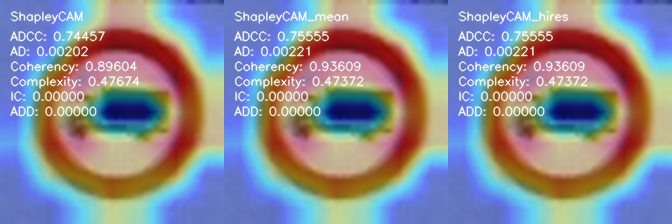

In [14]:
## mul
img_example = np.array(Image.open("./data/Test/00000.png"))
category = 16 # tench


img_example = np.array(Image.fromarray(img_example).resize((224, 224)))
img_example = np.float32(img_example) / 255
input_tensor = preprocess_image(img_example, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

swin_model.to(device)
input_tensor = input_tensor.to(device)
np.random.seed(42)
benchmark(img_example, input_tensor, target_layers, eigen_smooth=True, aug_smooth=True, category= category)

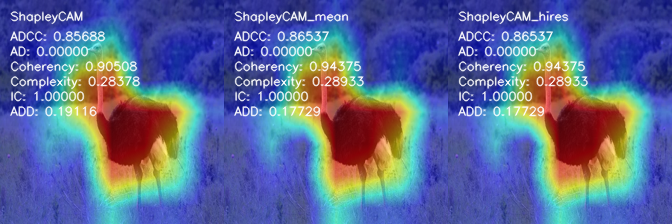

In [28]:
## mul
img_example = np.array(Image.open("../examples/ostrich.png")) 
category = 9 # ostrich


img_example = np.array(Image.fromarray(img_example).resize((224, 224)))
img_example = np.float32(img_example) / 255
input_tensor = preprocess_image(img_example, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

model
input_tensor = input_tensor
np.random.seed(42)
benchmark(img_example, input_tensor, target_layers, eigen_smooth=False, aug_smooth=False, category= category)

/Users/user/Documents/Inno/XAI/swin_shapleycam/shapleycam/pytorch_grad_cam/metrics/ADCC.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  B = attr_method(torch.tensor(explanation_map), targets)


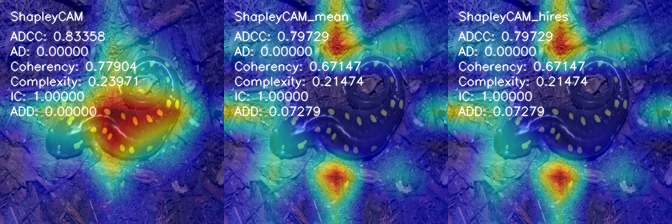

In [30]:
## mul
img_example = np.array(Image.open("../examples/spotted salamander.png")) 
category = 27 # spotted salamander


img_example = np.array(Image.fromarray(img_example).resize((224, 224)))
img_example = np.float32(img_example) / 255
input_tensor = preprocess_image(img_example, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# model.cuda()
# input_tensor = input_tensor.cuda()
np.random.seed(42)
benchmark(img_example, input_tensor, target_layers, eigen_smooth=False, aug_smooth=False, category= category)

100%|██████████| 64/64 [00:05<00:00, 11.11it/s]
/home/caihuaiguang/DSG/pytorch-shapley-cam/pytorch_grad_cam/metrics/ADCC.py:78: RuntimeWarning: divide by zero encountered in true_divide
  adcc = 3 / (1 / coh + 1 / (1 - com) + 1 / (1 - drop))


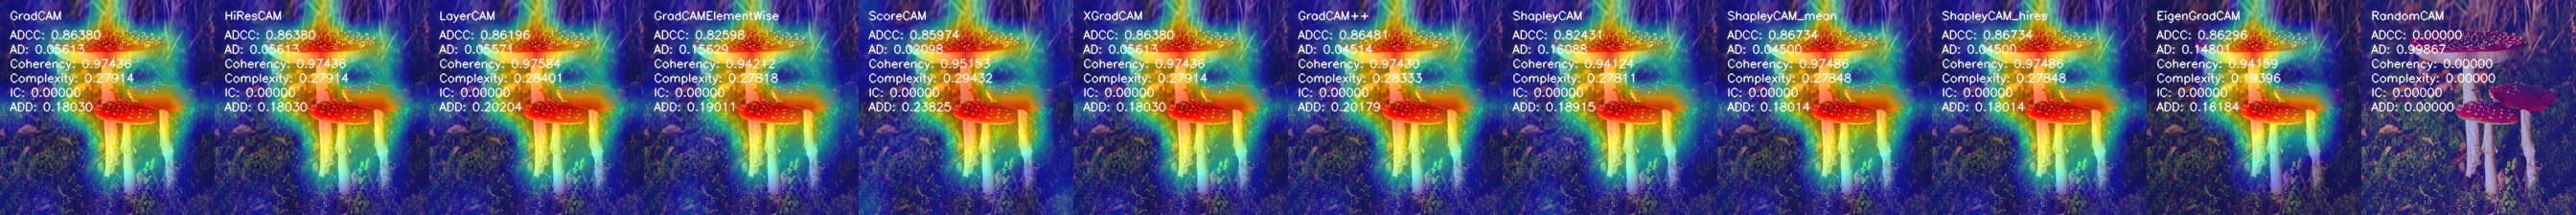

In [15]:
## mul
img_example = np.array(Image.open("./ILSVRC2012_val_00005745.JPEG")) # 992
category = 992 # agaric


img_example = np.array(Image.fromarray(img_example).resize((224, 224)))
img_example = np.float32(img_example) / 255
input_tensor = preprocess_image(img_example, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

model.cuda()
input_tensor = input_tensor.cuda()
np.random.seed(42)
benchmark(img_example, input_tensor, target_layers, eigen_smooth=False, aug_smooth=False, category= category)

100%|██████████| 64/64 [00:06<00:00, 10.28it/s]


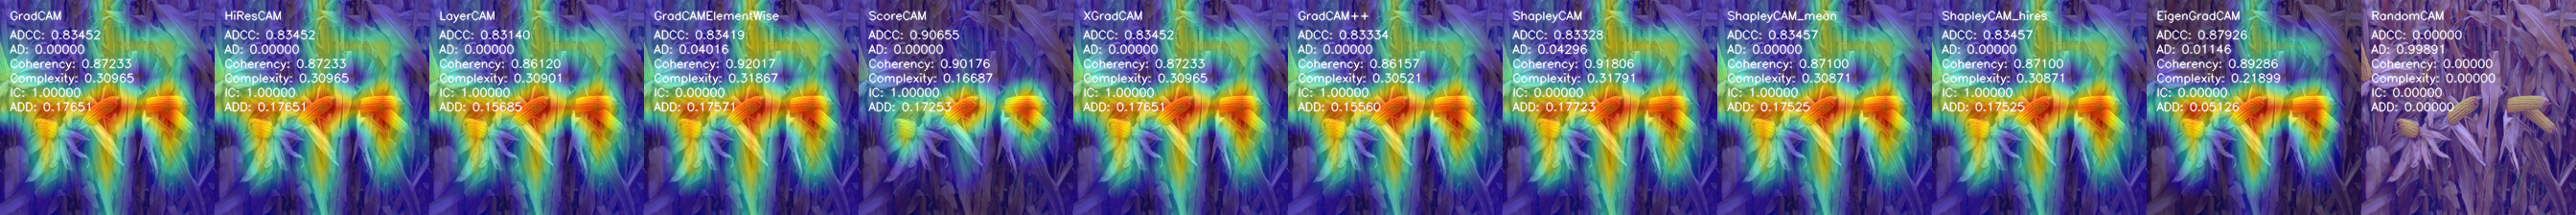

In [16]:
img_example = np.array(Image.open("./ILSVRC2012_val_00008440.JPEG")) 
category = 998 #spike


img_example = np.array(Image.fromarray(img_example).resize((224, 224)))
img_example = np.float32(img_example) / 255
input_tensor = preprocess_image(img_example, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

model.cuda()
input_tensor = input_tensor.cuda()
np.random.seed(42)
benchmark(img_example, input_tensor, target_layers, eigen_smooth=False, aug_smooth=False, category= category)

100%|██████████| 64/64 [00:06<00:00,  9.51it/s]


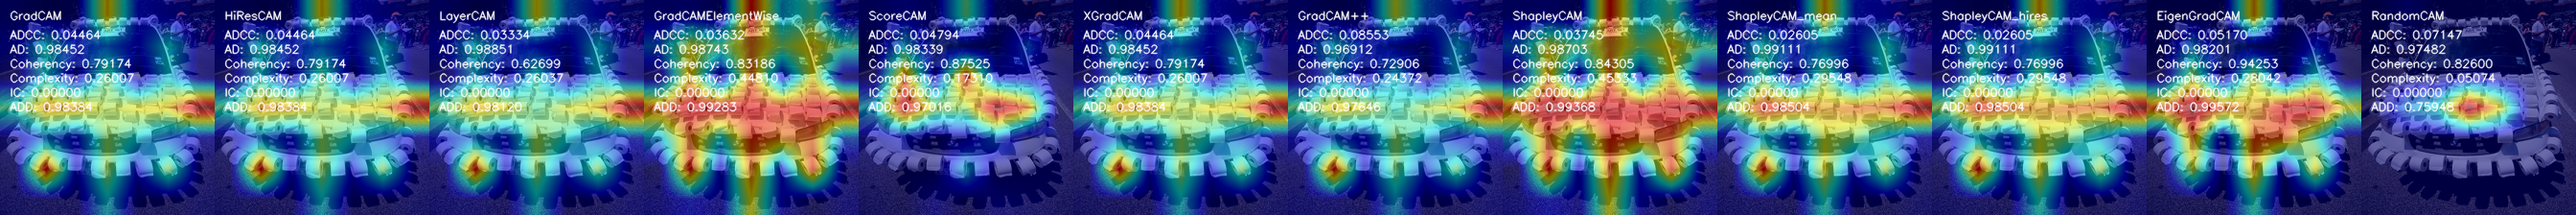

In [17]:
img_example = np.array(Image.open("./ILSVRC2012_val_00001079.JPEG")) 
category = 999 # toilet tissue


img_example = np.array(Image.fromarray(img_example).resize((224, 224)))
img_example = np.float32(img_example) / 255
input_tensor = preprocess_image(img_example, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

model.cuda()
input_tensor = input_tensor.cuda()
np.random.seed(42)
benchmark(img_example, input_tensor, target_layers, eigen_smooth=False, aug_smooth=False, category= category)

/Users/user/Documents/Inno/XAI/swin_shapleycam/shapleycam/pytorch_grad_cam/metrics/ADCC.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  B = attr_method(torch.tensor(explanation_map), targets)


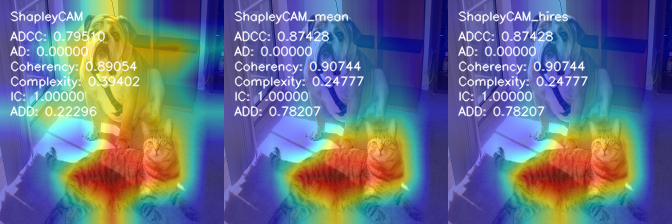

In [32]:
import requests
cat_and_dog_image_url = "https://raw.githubusercontent.com/jacobgil/pytorch-grad-cam/master/examples/both.png"
img_example = np.array(Image.open(requests.get(cat_and_dog_image_url, stream=True).raw))

# img_example = np.array(Image.open("../examples/both.png")) 

category = 281

 
img_example = np.float32(img_example) / 255
input_tensor = preprocess_image(img_example, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# model.cuda()
# input_tensor = input_tensor.cuda()
benchmark(img_example, input_tensor, target_layers, eigen_smooth=False, aug_smooth=False, category= category)

100%|██████████| 64/64 [00:07<00:00,  8.97it/s]


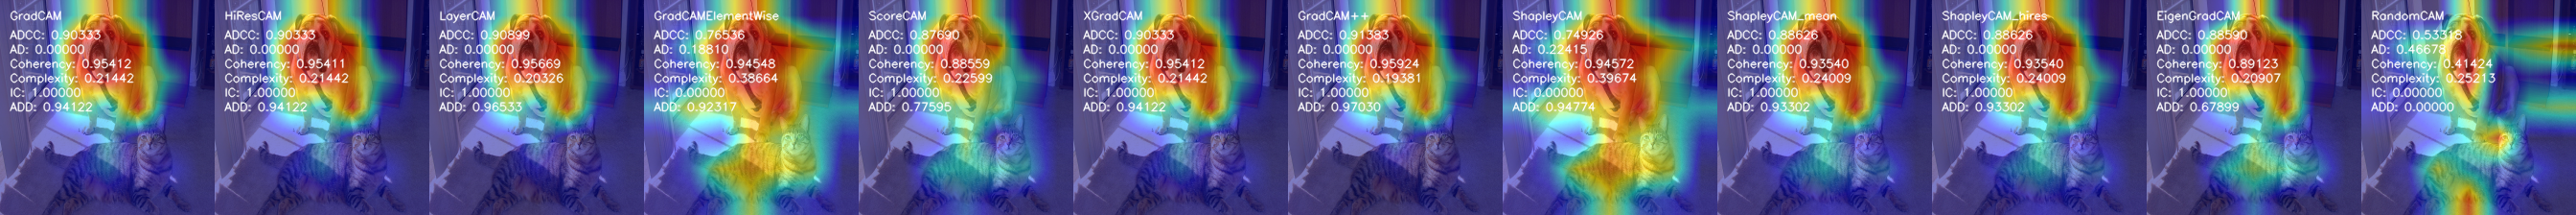

In [19]:
category = 243
# input_tensor = preprocess_image(img_example, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

model.cuda()
input_tensor = input_tensor.cuda()
benchmark(img_example, input_tensor, target_layers, eigen_smooth=False, aug_smooth=False, category= category)